# Notebook 6: Logistic Regression & Multiclass Classification
Part 6/30 – ML Mastery Series for Python Experts

## From Linear Regression to Logistic Regression

You already know that linear regression predicts continuous outputs via $\hat{y} = X\beta$. But what happens when we apply this to classification?

**The Problem:** Linear regression outputs unbounded values $(-\infty, +\infty)$, while classification requires probabilities in $[0, 1]$. Worse, ordinary least squares assumes Gaussian errors—clearly violated when $y \in \{0, 1\}$.

**The Solution:** Logistic regression models the *log-odds* (logit) as a linear function of the features:

$$\text{logit}(p) = \log\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1 x_1 + \dots + \beta_n x_n$$

Solving for $p$ yields the **sigmoid function**:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

where $z = X\beta$. The sigmoid squashes any real value into $(0, 1)$, interpretable as $P(y=1|X)$.

**Decision Boundary:** We predict class 1 when $\sigma(z) \geq 0.5$, which occurs when $z \geq 0$ (i.e., when the log-odds are non-negative). This creates a *linear decision boundary* in feature space.

## Learning Objectives

By the end of this notebook, you will:

- 🎯 Understand why linear regression fails for classification and how the sigmoid function fixes it
- 🎯 Interpret logistic regression coefficients as log-odds and convert them to odds ratios
- 🎯 Understand cross-entropy loss (log loss) and why it's the natural choice for probabilistic classification
- 🎯 Implement binary logistic regression using scikit-learn pipelines with proper scaling
- 🎯 Distinguish between One-vs-Rest (OvR) and Multinomial (Softmax) strategies for multiclass problems
- 🎯 Calibrate predicted probabilities using Platt scaling or isotonic regression
- 🎯 Evaluate classifiers using log-loss, Brier score, and ROC-AUC beyond simple accuracy
- 🎯 Apply regularization (L1/L2) and tune the regularization strength $C$ via cross-validation
- 🎯 Recognize when probability calibration matters for downstream decision-making

## 📊 1. Binary Classification Baseline – Iris (setosa vs rest)

Let's start with the classic Iris dataset, but reduce it to a binary problem: classify *Iris setosa* versus everything else. This gives us a clean, linearly separable case to build intuition.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# Configure plotting
%matplotlib inline
sns.set_theme(style="whitegrid", palette="husl")

# Load iris dataset
iris = load_iris()
X, y = iris.data, iris.target

# Create binary target: setosa = 1, others = 0
# Class 0 is setosa in the original dataset
y_bin = (y == 0).astype(int)

print(f"Feature names: {iris.feature_names}")
print(f"Class distribution: {np.bincount(y_bin)} (setosa=1, others=0)")
print(f"Features shape: {X.shape}")

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Class distribution: [100  50] (setosa=1, others=0)
Features shape: (150, 4)


In [2]:
# Stratified split to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.3, stratify=y_bin, random_state=42
)

print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")
print(f"Train class distribution: {np.bincount(y_train)}")
print(f"Test class distribution: {np.bincount(y_test)}")

Train set: (105, 4), Test set: (45, 4)
Train class distribution: [70 35]
Test class distribution: [30 15]


In [3]:
# Build pipeline: scaling is crucial for logistic regression
# Logistic regression uses gradient-based optimization; unscaled features slow convergence
pipeline = Pipeline([
    ('scaler', StandardScaler()),           # Zero mean, unit variance
    ('logreg', LogisticRegression(max_iter=1000, random_state=42))
])

# Fit the model
pipeline.fit(X_train, y_train)

# Extract the fitted classifier for inspection
clf = pipeline.named_steps['logreg']
print(f"Convergence: {clf.n_iter_} iterations")
print(f"Classes: {clf.classes_}")

Convergence: [9] iterations
Classes: [0 1]


In [4]:
# Predictions and probabilities
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]  # Probability of class 1 (setosa)
decision_values = pipeline.decision_function(X_test)  # Raw z = Xβ before sigmoid

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['others', 'setosa']))

# Show relationship between decision function and probabilities
print(f"\nDecision function range: [{decision_values.min():.2f}, {decision_values.max():.2f}]")
print(f"Probability range: [{y_proba.min():.4f}, {y_proba.max():.4f}]")

# Verify sigmoid relationship manually
manual_proba = 1 / (1 + np.exp(-decision_values))
print(f"Manual sigmoid matches predict_proba: {np.allclose(y_proba, manual_proba)}")

Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

      others       1.00      1.00      1.00        30
      setosa       1.00      1.00      1.00        15

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45


Decision function range: [-7.92, 5.76]
Probability range: [0.0004, 0.9968]
Manual sigmoid matches predict_proba: True


## 📊 2. Visualizing the Sigmoid & Decision Boundary

To visualize the decision boundary, we'll restrict ourselves to two features: petal length and width. This lets us plot the probability contours and see where the model is uncertain ($p \approx 0.5$).

In [5]:
# Use only petal length (index 2) and petal width (index 3)
X_2d = X[:, [2, 3]]
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y_bin, test_size=0.3, stratify=y_bin, random_state=42
)

# Fit 2D model
pipeline_2d = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000, random_state=42))
])
pipeline_2d.fit(X_train_2d, y_train_2d)

# Create mesh for contour plot
h = 0.02  # Step size
x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predict probabilities on mesh
mesh_points = np.c_[xx.ravel(), yy.ravel()]
Z = pipeline_2d.predict_proba(mesh_points)[:, 1].reshape(xx.shape)

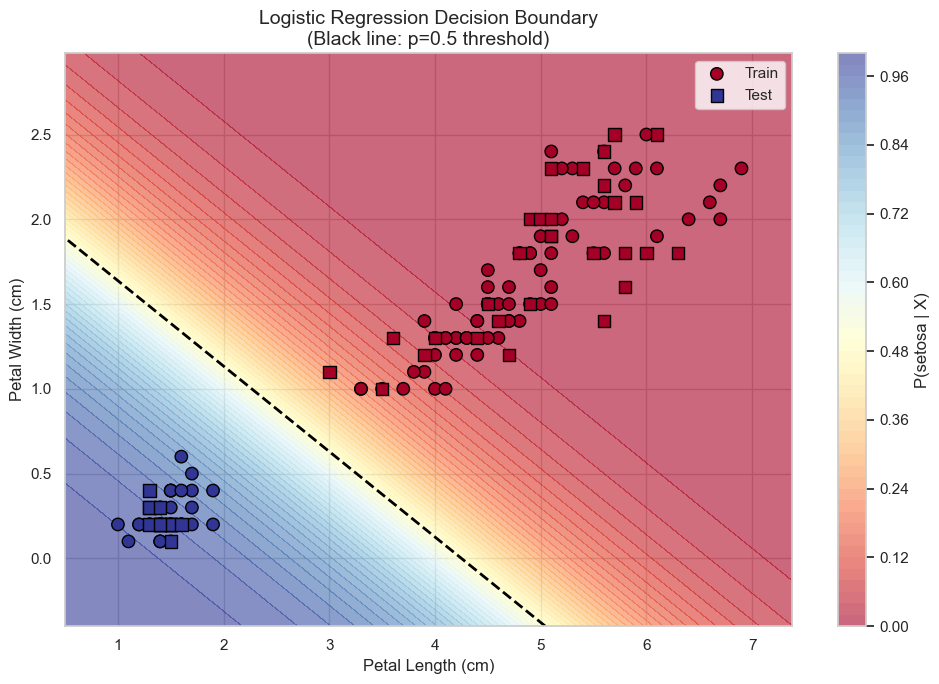

2D Model accuracy: 1.0000


In [6]:
# Plot decision boundary and probability contours
fig, ax = plt.subplots(figsize=(10, 7))

# Contour filled: probability of being setosa
contour = ax.contourf(xx, yy, Z, levels=50, cmap='RdYlBu', alpha=0.6, vmin=0, vmax=1)
plt.colorbar(contour, ax=ax, label='P(setosa | X)')

# Decision boundary at p=0.5 (where z=0)
# This is where log-odds = 0, i.e., the linear boundary
ax.contour(xx, yy, Z, levels=[0.5], colors='black', linestyles='--', linewidths=2)

# Scatter plot of actual data points
scatter = ax.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train_2d, 
                     cmap='RdYlBu', edgecolors='k', s=80, label='Train')
ax.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test_2d, 
           cmap='RdYlBu', edgecolors='k', s=80, marker='s', label='Test')

ax.set_xlabel('Petal Length (cm)', fontsize=12)
ax.set_ylabel('Petal Width (cm)', fontsize=12)
ax.set_title('Logistic Regression Decision Boundary\n(Black line: p=0.5 threshold)', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

print(f"2D Model accuracy: {pipeline_2d.score(X_test_2d, y_test_2d):.4f}")

## 📊 3. Interpreting Coefficients & Odds Ratios

One of logistic regression's superpowers is interpretability. The coefficients represent the change in *log-odds* for a one-unit increase in the feature. By exponentiating, we get **odds ratios**—the multiplicative effect on the odds.

In [7]:
# Get coefficients from the full 4-feature model
coef = clf.coef_[0]  # Shape (n_features,)
intercept = clf.intercept_[0]

# Create DataFrame for nice display
coef_df = pd.DataFrame({
    'Feature': iris.feature_names,
    'Coefficient (β)': coef,
    'Odds Ratio (exp(β))': np.exp(coef)
})

print("Logistic Regression Coefficients:")
print(f"Intercept (β₀): {intercept:.4f}")
print(coef_df.round(4))

print(f"\nInterpretation:")
print(f"- A one-unit increase in petal length decreases log-odds of being setosa by {abs(coef[2]):.4f}")
print(f"- This means the odds are multiplied by {np.exp(coef[2]):.4f} (i.e., reduced by {(1-np.exp(coef[2]))*100:.1f}%)")
print(f"- Petal width has the strongest negative effect: odds ratio = {np.exp(coef[3]):.4f}")

Logistic Regression Coefficients:
Intercept (β₀): -2.2427
             Feature  Coefficient (β)  Odds Ratio (exp(β))
0  sepal length (cm)          -0.8780               0.4156
1   sepal width (cm)           1.2630               3.5361
2  petal length (cm)          -1.6092               0.2001
3   petal width (cm)          -1.4784               0.2280

Interpretation:
- A one-unit increase in petal length decreases log-odds of being setosa by 1.6092
- This means the odds are multiplied by 0.2001 (i.e., reduced by 80.0%)
- Petal width has the strongest negative effect: odds ratio = 0.2280


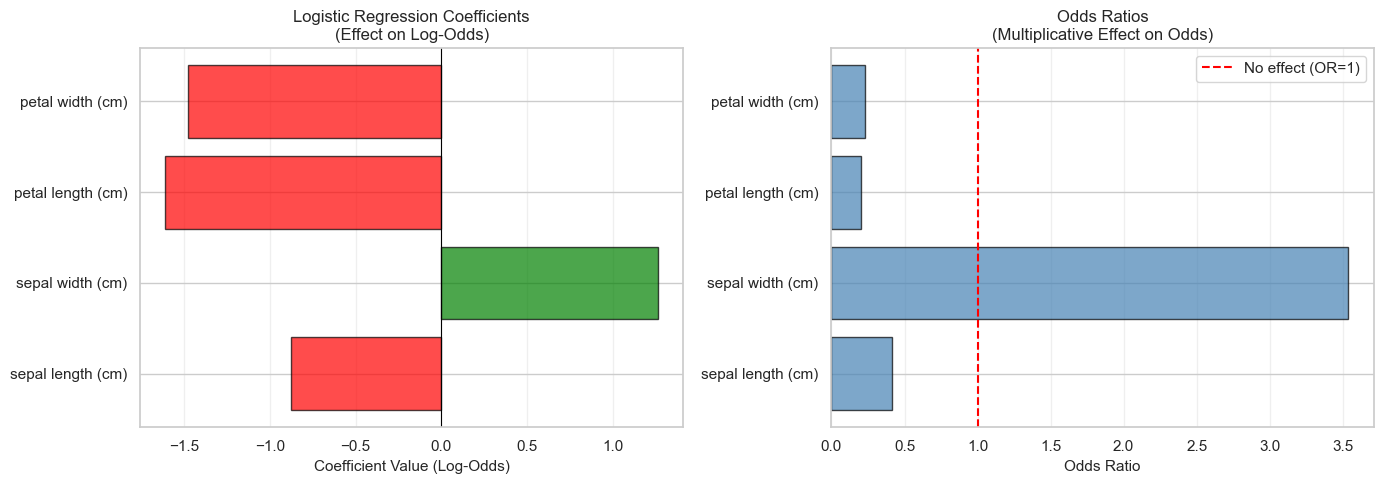

Key insight: Odds ratios > 1 increase the probability; < 1 decrease it.


In [8]:
# Visualize coefficients
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Raw coefficients
colors = ['green' if c > 0 else 'red' for c in coef]
ax1.barh(iris.feature_names, coef, color=colors, alpha=0.7, edgecolor='black')
ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax1.set_xlabel('Coefficient Value (Log-Odds)', fontsize=11)
ax1.set_title('Logistic Regression Coefficients\n(Effect on Log-Odds)', fontsize=12)
ax1.grid(axis='x', alpha=0.3)

# Odds ratios
odds_ratios = np.exp(coef)
ax2.barh(iris.feature_names, odds_ratios, color='steelblue', alpha=0.7, edgecolor='black')
ax2.axvline(x=1, color='red', linestyle='--', linewidth=1.5, label='No effect (OR=1)')
ax2.set_xlabel('Odds Ratio', fontsize=11)
ax2.set_title('Odds Ratios\n(Multiplicative Effect on Odds)', fontsize=12)
ax2.legend()
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("Key insight: Odds ratios > 1 increase the probability; < 1 decrease it.")

## 📊 4. Multiclass Strategies – One-vs-Rest (OvR) vs Multinomial (Softmax)

Now let's tackle all three Iris species. scikit-learn offers two strategies:

1. **One-vs-Rest (OvR):** Fit one binary classifier per class vs. all others. Simple, but probabilities may not sum to 1 without normalization.
2. **Multinomial (Softmax):** Directly model $P(y=k|X) = \frac{e^{z_k}}{\sum_j e^{z_j}}$. More principled, ensures probabilities sum to 1, and captures correlations between classes.

The loss function for multinomial is the **cross-entropy** (log loss):
$$L = -\sum_{i=1}^N \sum_{k=1}^K y_{ik} \log(p_{ik})$$

In [9]:
from sklearn.metrics import log_loss, confusion_matrix

# Full multiclass problem (3 classes)
X_train_mc, X_test_mc, y_train_mc, y_test_mc = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Strategy 1: One-vs-Rest
ovr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(multi_class='ovr', max_iter=1000, random_state=42))
])

# Strategy 2: Multinomial (Softmax)
multi_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42))
])

# Fit both
ovr_pipeline.fit(X_train_mc, y_train_mc)
multi_pipeline.fit(X_train_mc, y_train_mc)

# Predictions
ovr_pred = ovr_pipeline.predict(X_test_mc)
multi_pred = multi_pipeline.predict(X_test_mc)

# Probabilities
ovr_proba = ovr_pipeline.predict_proba(X_test_mc)
multi_proba = multi_pipeline.predict_proba(X_test_mc)

print(f"OvR Accuracy: {accuracy_score(y_test_mc, ovr_pred):.4f}")
print(f"Multinomial Accuracy: {accuracy_score(y_test_mc, multi_pred):.4f}")
print(f"\nOvR Log Loss: {log_loss(y_test_mc, ovr_proba):.4f}")
print(f"Multinomial Log Loss: {log_loss(y_test_mc, multi_proba):.4f}")

# Verify probability sums
print(f"\nOvR probabilities sum to 1 (check): {np.allclose(ovr_proba.sum(axis=1), 1)}")
print(f"Multinomial probabilities sum to 1 (check): {np.allclose(multi_proba.sum(axis=1), 1)}")

OvR Accuracy: 0.8444
Multinomial Accuracy: 0.9111

OvR Log Loss: 0.3651
Multinomial Log Loss: 0.2096

OvR probabilities sum to 1 (check): True
Multinomial probabilities sum to 1 (check): True


c:\Users\786\miniconda3\envs\env_dl\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\786\miniconda3\envs\env_dl\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


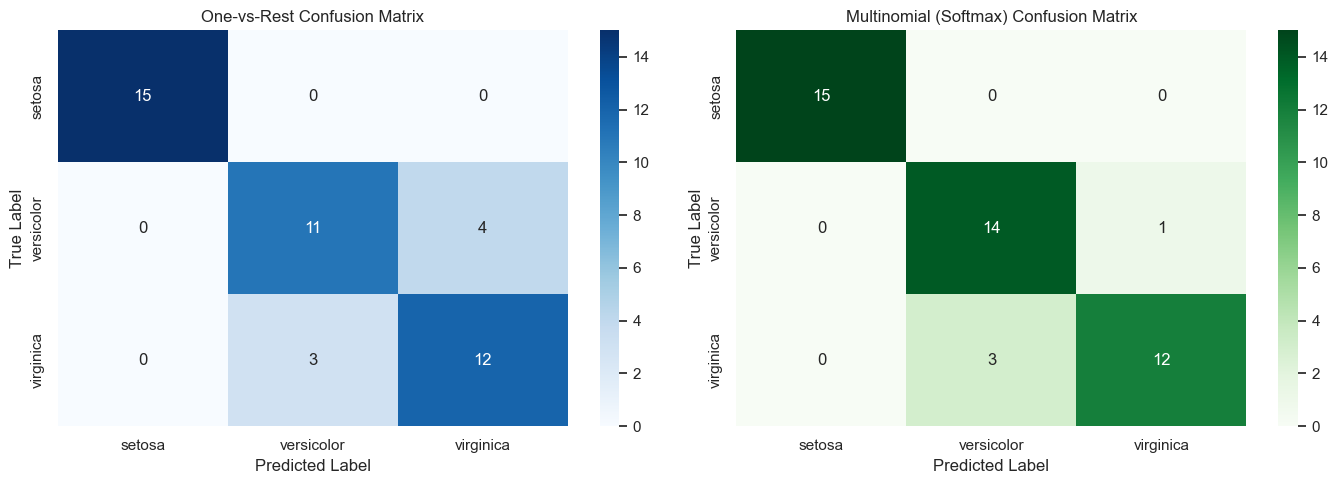

Note: Both strategies perform similarly on this well-separated dataset.


In [10]:
# Confusion matrices comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# OvR confusion matrix
cm_ovr = confusion_matrix(y_test_mc, ovr_pred)
sns.heatmap(cm_ovr, annot=True, fmt='d', cmap='Blues', 
            xticklabels=iris.target_names, yticklabels=iris.target_names, ax=axes[0])
axes[0].set_title('One-vs-Rest Confusion Matrix', fontsize=12)
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Multinomial confusion matrix
cm_multi = confusion_matrix(y_test_mc, multi_pred)
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Greens',
            xticklabels=iris.target_names, yticklabels=iris.target_names, ax=axes[1])
axes[1].set_title('Multinomial (Softmax) Confusion Matrix', fontsize=12)
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

print("Note: Both strategies perform similarly on this well-separated dataset.")

In [11]:
# Compare predicted probabilities for first 5 test samples
proba_df = pd.DataFrame({
    'True Class': [iris.target_names[i] for i in y_test_mc[:5]],
    'OvR: setosa': ovr_proba[:5, 0].round(4),
    'OvR: versicolor': ovr_proba[:5, 1].round(4),
    'OvR: virginica': ovr_proba[:5, 2].round(4),
    'Multi: setosa': multi_proba[:5, 0].round(4),
    'Multi: versicolor': multi_proba[:5, 1].round(4),
    'Multi: virginica': multi_proba[:5, 2].round(4),
})

print("Predicted Probabilities Comparison (first 5 samples):")
print(proba_df.to_string(index=False))

print(f"\nOvR uses {len(ovr_pipeline.named_steps['logreg'].coef_)} separate binary classifiers")
print(f"Multinomial uses {len(multi_pipeline.named_steps['logreg'].coef_)} coefficient vectors jointly optimized")

Predicted Probabilities Comparison (first 5 samples):
True Class  OvR: setosa  OvR: versicolor  OvR: virginica  Multi: setosa  Multi: versicolor  Multi: virginica
 virginica       0.0002           0.3641          0.6356         0.0000             0.1014            0.8985
versicolor       0.0220           0.6585          0.3195         0.0141             0.7894            0.1964
 virginica       0.0054           0.5665          0.4280         0.0036             0.6202            0.3762
versicolor       0.0398           0.2904          0.6698         0.0218             0.6292            0.3490
 virginica       0.0082           0.3169          0.6749         0.0052             0.3846            0.6103

OvR uses 3 separate binary classifiers
Multinomial uses 3 coefficient vectors jointly optimized


## 📊 5. Probability Calibration – When & Why It Matters

Not all probabilistic classifiers produce well-calibrated probabilities. A model is **well-calibrated** if when it predicts $p = 0.8$, the event actually occurs 80% of the time. Miscalibration is dangerous when probabilities feed into downstream decisions (e.g., medical diagnosis thresholds, bidding systems).

We'll use `CalibratedClassifierCV` with two methods:
- **Sigmoid (Platt scaling):** Fits a logistic regression on the raw classifier scores. Assumes sigmoid-shaped distortion.
- **Isotonic:** Non-parametric approach, more flexible but needs more data.

In [13]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss

# Create a slightly overconfident model for demonstration
# We'll use a smaller regularization to make it overfit a bit
base_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(C=1000, max_iter=1000, random_state=42))
])

# Split training data further for calibration
X_train_base, X_cal, y_train_base, y_cal = train_test_split(
    X_train, y_train, test_size=0.3, stratify=y_train, random_state=42
)

# Fit base model
base_clf.fit(X_train_base, y_train_base)
base_proba = base_clf.predict_proba(X_test)[:, 1]

# Calibrated models
calibrated_sigmoid = CalibratedClassifierCV(base_clf, method='sigmoid', cv='prefit')
calibrated_isotonic = CalibratedClassifierCV(base_clf, method='isotonic', cv='prefit')

calibrated_sigmoid.fit(X_cal, y_cal)
calibrated_isotonic.fit(X_cal, y_cal)

# Get calibrated probabilities
sigmoid_proba = calibrated_sigmoid.predict_proba(X_test)[:, 1]
isotonic_proba = calibrated_isotonic.predict_proba(X_test)[:, 1]

# Brier scores (lower is better, measures calibration + refinement)
print("Brier Scores (lower is better):")
print(f"  Uncalibrated: {brier_score_loss(y_test, base_proba):.4f}")
print(f"  Sigmoid:      {brier_score_loss(y_test, sigmoid_proba):.4f}")
print(f"  Isotonic:     {brier_score_loss(y_test, isotonic_proba):.4f}")

Brier Scores (lower is better):
  Uncalibrated: 0.0001
  Sigmoid:      0.0088
  Isotonic:     0.0036


c:\Users\786\miniconda3\envs\env_dl\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
c:\Users\786\miniconda3\envs\env_dl\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


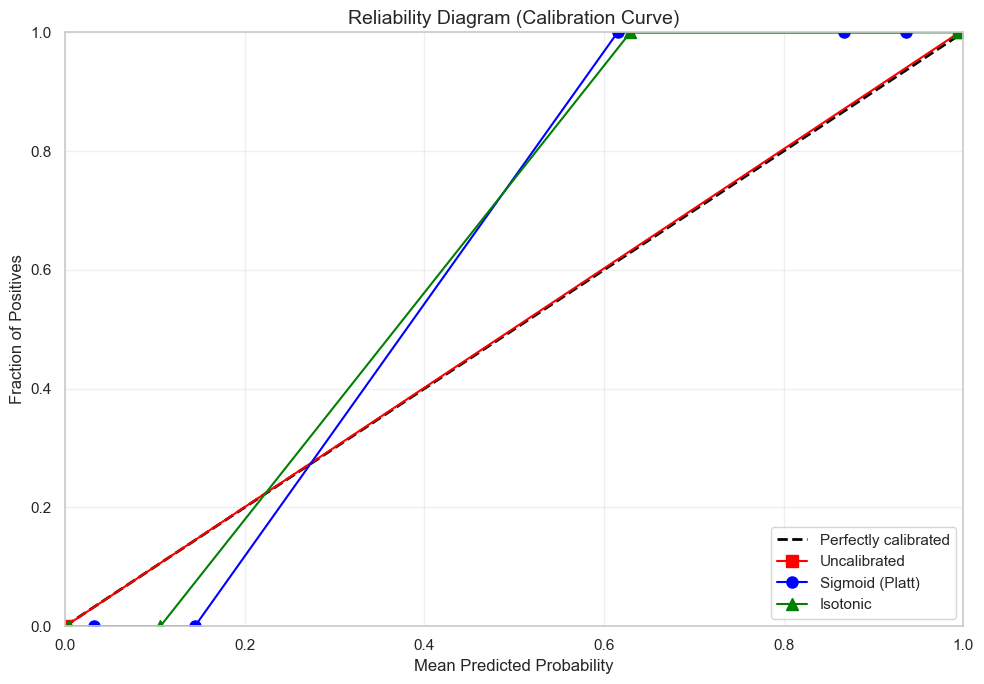

Diagonal = perfect calibration. Points below diagonal = overconfident (predicting too high).


In [14]:
# Reliability diagrams (calibration curves)
fig, ax = plt.subplots(figsize=(10, 7))

# Compute calibration curves
prob_true_base, prob_pred_base = calibration_curve(y_test, base_proba, n_bins=10)
prob_true_sig, prob_pred_sig = calibration_curve(y_test, sigmoid_proba, n_bins=10)
prob_true_iso, prob_pred_iso = calibration_curve(y_test, isotonic_proba, n_bins=10)

# Plot perfect calibration
ax.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated', linewidth=2)

# Plot model calibrations
ax.plot(prob_pred_base, prob_true_base, 's-', label='Uncalibrated', color='red', markersize=8)
ax.plot(prob_pred_sig, prob_true_sig, 'o-', label='Sigmoid (Platt)', color='blue', markersize=8)
ax.plot(prob_pred_iso, prob_true_iso, '^-', label='Isotonic', color='green', markersize=8)

ax.set_xlabel('Mean Predicted Probability', fontsize=12)
ax.set_ylabel('Fraction of Positives', fontsize=12)
ax.set_title('Reliability Diagram (Calibration Curve)', fontsize=14)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

print("Diagonal = perfect calibration. Points below diagonal = overconfident (predicting too high).")

## 📊 6. Evaluation Beyond Accuracy – Log Loss & ROC-AUC (OvR)

For classification, accuracy can be misleading—especially with imbalanced classes. We need metrics that evaluate the quality of predicted probabilities.

**Log Loss (Cross-Entropy):** Penalizes confident wrong predictions heavily.
$$\text{Log Loss} = -\frac{1}{N}\sum_{i=1}^N \sum_{k=1}^K y_{ik} \log(p_{ik})$$

**ROC-AUC:** Area under the ROC curve. For multiclass, we use OvR or OvO averaging.

**Brier Score:** Mean squared error of predicted probabilities.
$$\text{Brier} = \frac{1}{N}\sum_{i=1}^N (p_i - y_i)^2$$

In [15]:
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

# Use the multiclass models from section 4
# Binarize labels for ROC-AUC computation
y_test_bin = label_binarize(y_test_mc, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# Compute ROC curve and ROC area for each class (OvR)
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], multi_proba[:, i])
    roc_auc[i] = roc_auc_score(y_test_bin[:, i], multi_proba[:, i])

# Compute micro-average ROC curve
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), multi_proba.ravel())
roc_auc["micro"] = roc_auc_score(y_test_bin, multi_proba, average='micro')

print(f"Multinomial Model Evaluation:")
print(f"  Log Loss: {log_loss(y_test_mc, multi_proba):.4f}")
print(f"  Micro-average ROC-AUC: {roc_auc['micro']:.4f}")
print(f"  Per-class ROC-AUC:")
for i, name in enumerate(iris.target_names):
    print(f"    {name}: {roc_auc[i]:.4f}")

Multinomial Model Evaluation:
  Log Loss: 0.2096
  Micro-average ROC-AUC: 0.9938
  Per-class ROC-AUC:
    setosa: 1.0000
    versicolor: 0.9933
    virginica: 0.9933


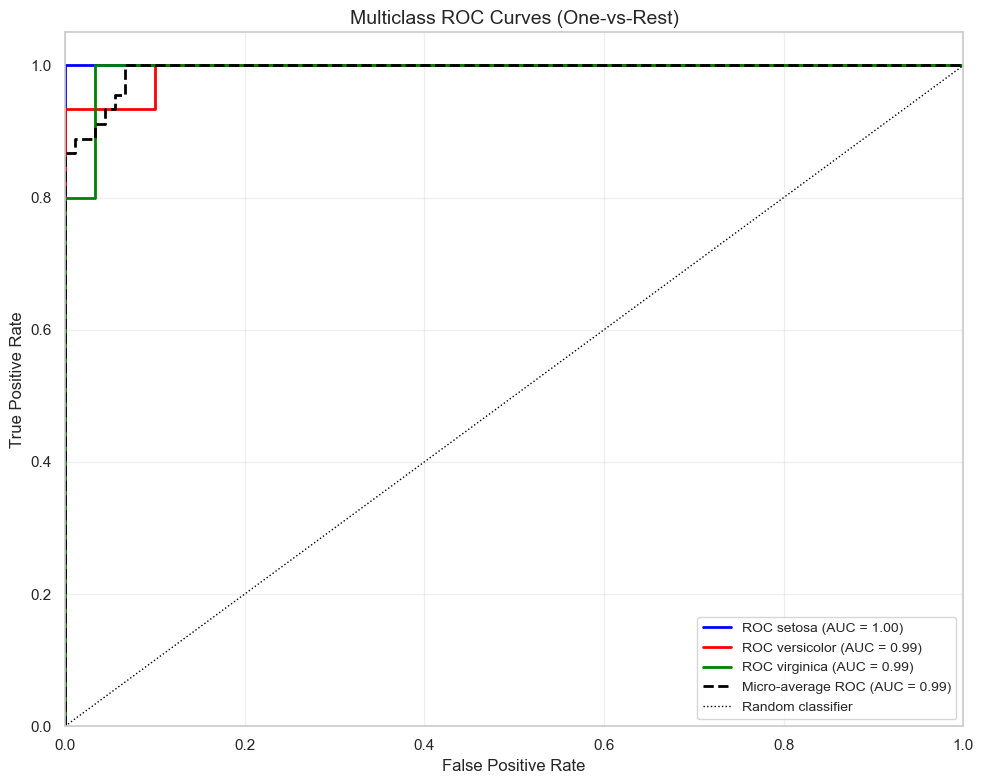

Perfect classifier reaches top-left corner (FPR=0, TPR=1).


In [16]:
# Plot ROC curves
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['blue', 'red', 'green']
for i, color in enumerate(colors):
    ax.plot(fpr[i], tpr[i], color=color, lw=2,
            label=f'ROC {iris.target_names[i]} (AUC = {roc_auc[i]:.2f})')

ax.plot(fpr["micro"], tpr["micro"], 'k--', lw=2,
        label=f'Micro-average ROC (AUC = {roc_auc["micro"]:.2f})')

ax.plot([0, 1], [0, 1], 'k:', lw=1, label='Random classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Multiclass ROC Curves (One-vs-Rest)', fontsize=14)
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Perfect classifier reaches top-left corner (FPR=0, TPR=1).")

## 📊 7. Regularization in Logistic Regression

Logistic regression in scikit-learn applies L2 regularization by default. The hyperparameter $C$ is the **inverse** of regularization strength: smaller $C$ = stronger regularization = simpler model = coefficients shrunk toward zero.

Regularization helps prevent overfitting, especially with high-dimensional data or correlated features.

In [17]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid: C values spanning several orders of magnitude
param_grid = {
    'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

# Pipeline with placeholder C
reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000, random_state=42))
])

# Grid search with cross-validation
grid_search = GridSearchCV(
    reg_pipeline, param_grid, cv=5, scoring='neg_log_loss', n_jobs=-1
)
grid_search.fit(X_train_mc, y_train_mc)

print("Best parameters:", grid_search.best_params_)
print(f"Best CV log loss: {-grid_search.best_score_:.4f}")

# Collect results
results = pd.DataFrame(grid_search.cv_results_)
results['mean_log_loss'] = -results['mean_test_score']
results['std_log_loss'] = results['std_test_score']

Best parameters: {'logreg__C': 100}
Best CV log loss: 0.0515


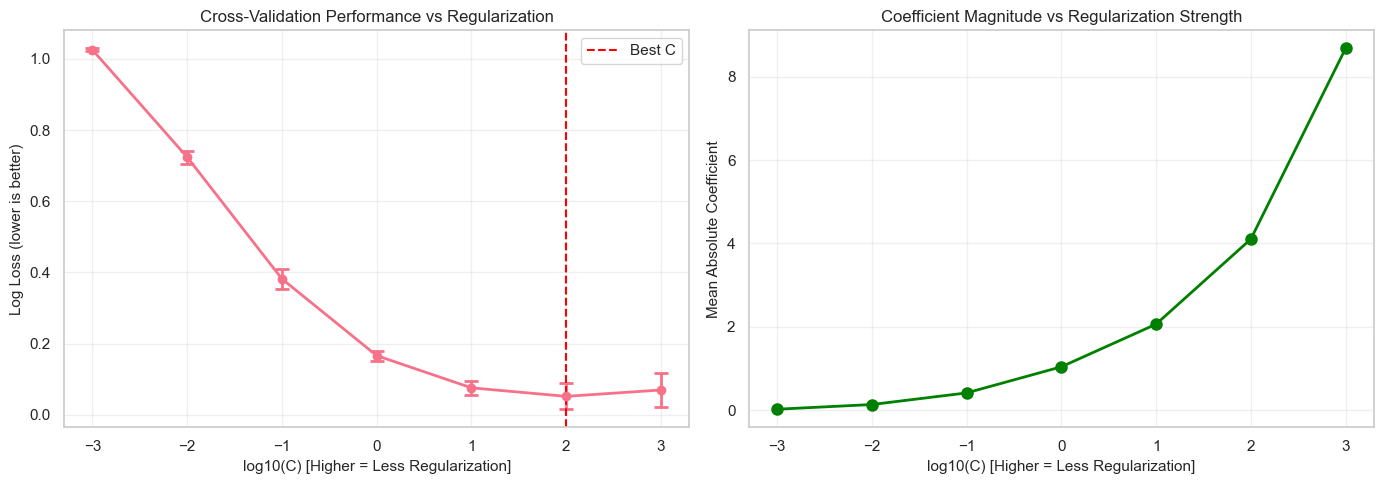

Observation: Strong regularization (small C) shrinks coefficients toward zero.


In [18]:
# Visualize regularization path
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot CV scores
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
ax1.errorbar(np.log10(C_values), results['mean_log_loss'], 
             yerr=results['std_log_loss'], marker='o', capsize=5, capthick=2, linewidth=2)
ax1.set_xlabel('log10(C) [Higher = Less Regularization]', fontsize=11)
ax1.set_ylabel('Log Loss (lower is better)', fontsize=11)
ax1.set_title('Cross-Validation Performance vs Regularization', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.axvline(x=np.log10(grid_search.best_params_['logreg__C']), 
            color='red', linestyle='--', label='Best C')
ax1.legend()

# Plot coefficient magnitudes for different C values
coef_magnitudes = []
for C in C_values:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('logreg', LogisticRegression(C=C, max_iter=1000, random_state=42))
    ])
    pipe.fit(X_train_mc, y_train_mc)
    # Average absolute coefficient across all classes
    avg_coef = np.mean(np.abs(pipe.named_steps['logreg'].coef_))
    coef_magnitudes.append(avg_coef)

ax2.plot(np.log10(C_values), coef_magnitudes, 'o-', linewidth=2, markersize=8, color='green')
ax2.set_xlabel('log10(C) [Higher = Less Regularization]', fontsize=11)
ax2.set_ylabel('Mean Absolute Coefficient', fontsize=11)
ax2.set_title('Coefficient Magnitude vs Regularization Strength', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Observation: Strong regularization (small C) shrinks coefficients toward zero.")

## Common Pitfalls & Pro Tips

🚫 **Don't use accuracy on imbalanced data.** A classifier that always predicts the majority class can have 99% accuracy but be useless. Use F1, ROC-AUC, or log-loss instead.

🚫 **Don't interpret raw coefficients without exponentiating.** Coefficients are in log-odds space; odds ratios ($e^\beta$) are interpretable as multiplicative effects.

🚫 **Don't forget to scale features.** Logistic regression assumes features are on similar scales for regularization to work properly. Always use `StandardScaler` in pipelines.

🚫 **Don't default to OvR for multiclass.** While OvR is the default for some solvers, multinomial often performs better and gives true probability distributions.

🚫 **Don't ignore probability calibration.** If you're using predicted probabilities for thresholding or downstream decisions, always check calibration with reliability diagrams.

🚫 **Don't use `solver='liblinear'` for large datasets.** It's limited to OvR and one-vs-rest. Use `'lbfgs'`, `'sag'`, or `'saga'` for multiclass and large data.

🚫 **Don't forget convergence warnings.** Increase `max_iter` if you see convergence warnings, or check if features need scaling.

✅ **Do check for multicollinearity.** Highly correlated features can make coefficients unstable. Consider VIF or PCA.

✅ **Do use stratified sampling.** Always stratify train/test splits to maintain class distributions.

## Exercises

### 🟢 Easy: Binary Classification on Breast Cancer Dataset
Load `sklearn.datasets.load_breast_cancer()`, select two features (e.g., mean radius and mean texture), and fit a binary logistic regression. Plot the decision boundary and report the odds ratios. Which feature has a stronger effect on malignancy prediction?

### 🟡 Medium: Compare OvR vs Multinomial on Digits Dataset
Load `sklearn.datasets.load_digits()` (10 classes). Compare OvR and Multinomial strategies using both accuracy and log-loss. Which performs better? Visualize the confusion matrix for the better-performing model.

### 🟡 Medium: L1 Regularization and Sparsity
Using the breast cancer dataset, fit logistic regression with `penalty='l1'` and `solver='liblinear'` (or `'saga'`). Try different C values and plot how many coefficients become exactly zero (sparsity) as you decrease C. L1 regularization performs feature selection!

### 🔴 Hard: Calibration Function
Write a function `fit_calibrated_logreg(X_train, y_train, X_cal, y_cal, X_test, method='sigmoid')` that:
1. Fits a logistic regression on training data
2. Calibrates it on calibration data using the specified method
3. Returns calibrated probabilities and Brier score on test data

Test it on a synthetic dataset from `make_classification` with class imbalance.

### 🔵 Bonus: Wine Dataset Evaluation
Load `sklearn.datasets.load_wine()` (3 classes). Compare OvR vs Multinomial using:
- Accuracy
- Log-loss
- Macro-averaged ROC-AUC
- Calibration curves for each class

Which strategy is more appropriate for this dataset and why?

<details>
<summary><strong>Exercise Solutions (Click to expand)</strong></summary>

### Easy Solution: Breast Cancer Binary

```python
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
X_cancer = cancer.data[:, [0, 1]]  # radius and texture
y_cancer = cancer.target

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer, y_cancer, test_size=0.3, stratify=y_cancer, random_state=42
)

pipe_cancer = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000))
])
pipe_cancer.fit(X_train_c, y_train_c)

# Odds ratios
coefs = pipe_cancer.named_steps['logreg'].coef_[0]
print(f"Radius odds ratio: {np.exp(coefs[0]):.4f}")
print(f"Texture odds ratio: {np.exp(coefs[1]):.4f}")
```

### Medium Solution: Digits OvR vs Multinomial

```python
from sklearn.datasets import load_digits

digits = load_digits()
X_d, y_d = digits.data, digits.target

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_d, y_d, test_size=0.3, stratify=y_d, random_state=42
)

for strategy in ['ovr', 'multinomial']:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('logreg', LogisticRegression(multi_class=strategy, max_iter=2000, solver='lbfgs'))
    ])
    pipe.fit(X_train_d, y_train_d)
    proba = pipe.predict_proba(X_test_d)
    print(f"{strategy}: Acc={pipe.score(X_test_d, y_test_d):.4f}, LogLoss={log_loss(y_test_d, proba):.4f}")
```

### Hard Solution: Calibration Function

```python
def fit_calibrated_logreg(X_train, y_train, X_cal, y_cal, X_test, y_test, method='sigmoid'):
    base = Pipeline([
        ('scaler', StandardScaler()),
        ('logreg', LogisticRegression(max_iter=1000))
    ])
    base.fit(X_train, y_train)
    
    calibrated = CalibratedClassifierCV(base, method=method, cv='prefit')
    calibrated.fit(X_cal, y_cal)
    
    proba = calibrated.predict_proba(X_test)[:, 1]
    brier = brier_score_loss(y_test, proba)
    return proba, brier
```

</details>

## Summary – What You Learned Today

✅ **Mathematical Foundations:** You understand why linear regression fails for classification and how the sigmoid function maps real-valued outputs to valid probabilities.

✅ **Interpretability:** You can convert coefficients to odds ratios and explain the multiplicative effect of features on the odds of the positive class.

✅ **Multiclass Strategies:** You can distinguish between One-vs-Rest and Multinomial (Softmax) approaches, and you know when each is appropriate.

✅ **Probability Calibration:** You recognize the importance of well-calibrated probabilities and can apply Platt scaling or isotonic regression to fix miscalibration.

✅ **Proper Evaluation:** You moved beyond accuracy to use log-loss, Brier score, and ROC-AUC—metrics that evaluate the quality of predicted probabilities.

✅ **Regularization:** You understand how the $C$ parameter controls model complexity and how to tune it via cross-validation.

---

**Auther**: Tassawar Abbas  
**Email**: abbas829@gmail.com